/tmp/ipykernel_41557/1200943241.py:108: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)


Saving figure california_housing_prices_plot


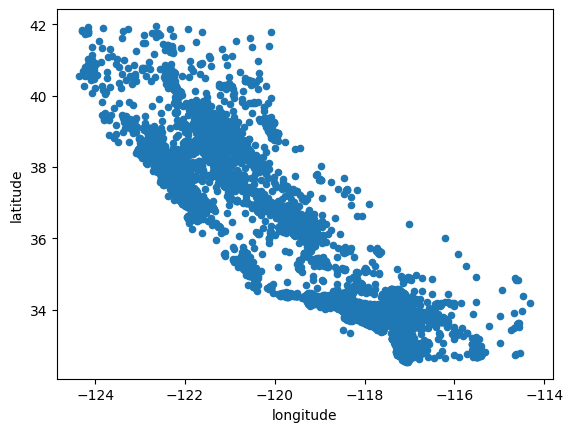

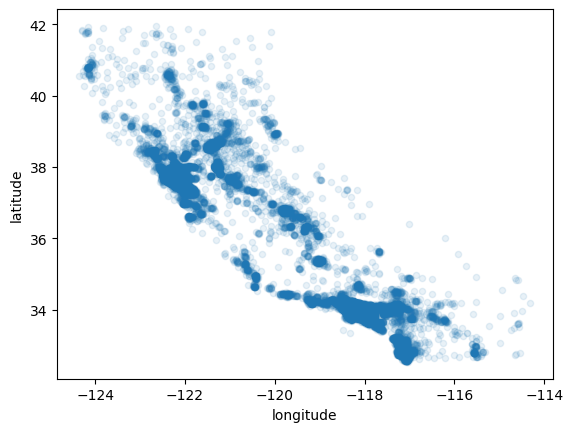

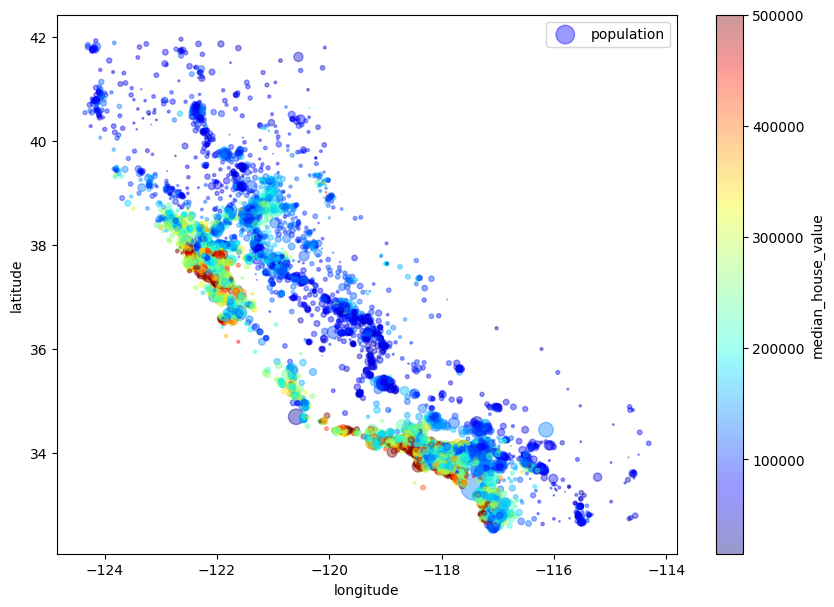

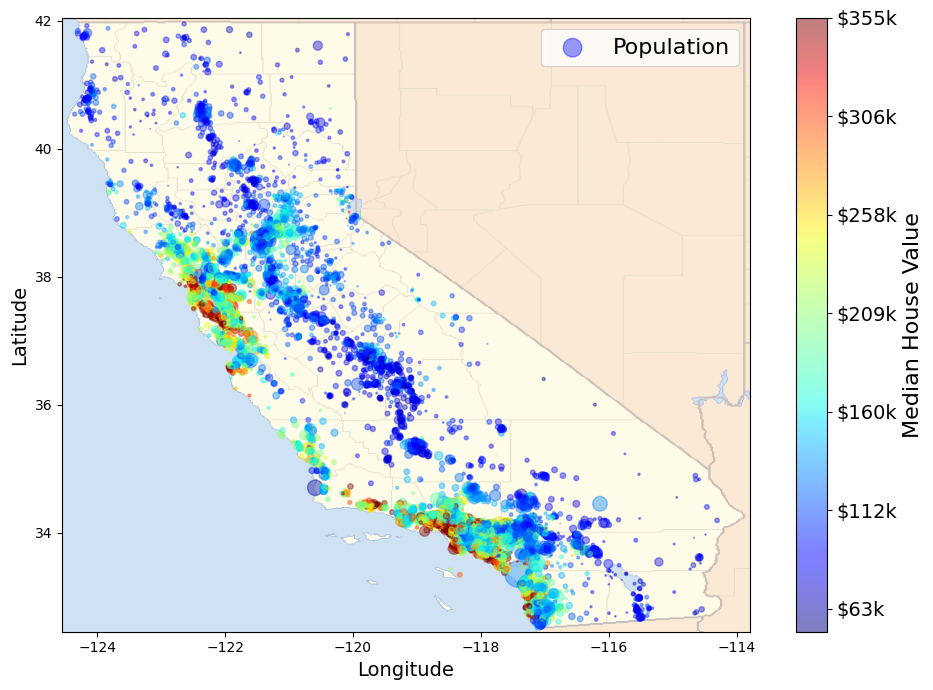

ValueError: could not convert string to float: 'INLAND'

In [25]:
import os
import pandas as pd

HOUSING_PATH = "./"

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join("./", fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housing = load_housing_data()

def split_train_test_by_lib():
    from sklearn.model_selection import train_test_split
    return train_test_split(housing, test_size=0.2, random_state=42)

def limit_test():
    import numpy as np
    #housing["median_income"].hist()
    housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)  # Divide by 1.5 to limit the number of income categories
    #housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)    # Label those above 5 as 5
    housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])
    #housing["income_cat"].value_counts()
    #housing["income_cat"].hist()

def fenceng_split():
    from sklearn.model_selection import StratifiedShuffleSplit
    split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    for train_index, test_index in split.split(housing, housing["income_cat"]):
        strat_train_set = housing.loc[train_index]
        strat_test_set = housing.loc[test_index]       
    return strat_train_set, strat_test_set

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

limit_test()
#housing["income_cat"].value_counts()

train_set, test_set = split_train_test_by_lib()
strat_train_set, strat_test_set = fenceng_split()

#strat_test_set["income_cat"].value_counts() / len(strat_test_set)
#housing["income_cat"].value_counts() / len(housing) #每个收入等级 取样比例

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100


housing = strat_train_set.copy()
housing.plot(kind="scatter", x="longitude", y="latitude")   #图1
#save_fig("bad_visualization_plot")


housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)  #图2
#save_fig("better_visualization_plot")

import matplotlib.pyplot as plt
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,  #图3
    s=housing["population"]/100, label="population", figsize=(10,7),
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
    sharex=False)
plt.legend()
#save_fig("housing_prices_scatterplot")

'''
#下载地图
import urllib.request
images_path = os.path.join('./', "images", "end_to_end_project")
os.makedirs(images_path, exist_ok=True)
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
filename = "california.png"
#print("Downloading", filename)
url = DOWNLOAD_ROOT + "images/end_to_end_project/" + filename
urllib.request.urlretrieve(url, os.path.join(images_path, filename))
print("Downloaded", filename)
'''
import numpy as np

import matplotlib.image as mpimg
california_img=mpimg.imread('./' + 'california.png')
ax = housing.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                       s=housing['population']/100, label="Population",
                       c="median_house_value", cmap=plt.get_cmap("jet"),
                       colorbar=False, alpha=0.4,
                      )
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = housing["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar()
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)
save_fig("california_housing_prices_plot")
plt.show()


